In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_diag = pd.read_csv("diagnosis.csv")
df_diag.head()

,DiagnosisKey,GroupName,GroupCode,DiagnosisName,DiagnosisValue
0,2.0,Typhoid and paratyphoid fevers,ICD-10-CM: A01,"Paratyphoid fever, unspecified( ICD-10-CM: A01...",A01.4
1,3.0,Respiratory tuberculosis,ICD-10-CM: A15,Primary respiratory tuberculosis( ICD-10-CM: A...,A15.7
2,7.0,Fracture at wrist and hand level,ICD-10-CM: S62,"Displaced fracture of pisiform, unspecified wr...",S62.163K
3,8.0,Fracture of rib,ICD-10-CM: S22,"Multiple fractures of ribs, right side, subseq...",S22.41XG
4,9.0,Fracture at wrist and hand level,ICD-10-CM: S62,Nondisplaced fracture of distal phalanx of lef...,S62.663G


In [3]:
df_pat = pd.read_csv("patients.csv")
df_pat.head()

,CensusBlockGroupFipsCode,DurableKey,FirstRace,MaritalStatus,MyChartStatus,OmbEthnicity,OmbRace,SexAssignedAtBirth,SexualOrientation,SmokingStatus,VitalStatus,PatientBirthYearBin
0,201770007002,5.0,White or Caucasian,Single,Activated,Not Hispanic or Latino,White,*Unspecified,*Unspecified,Never,Alive,1970.0
1,*Unspecified,8.0,White or Caucasian,*Unspecified,Inactivated,Unknown,White,*Unspecified,*Unspecified,*Unknown,Alive,1980.0
2,*Unspecified,9.0,"Hispanic, Latino, or Spanish",Married,*Unspecified,Unknown,Some Other Race,*Unspecified,*Unspecified,Never,Alive,1955.0
3,*Unspecified,11.0,"Hispanic, Latino, or Spanish",Unknown,*Unspecified,Hispanic or Latino,Some Other Race,*Unspecified,*Unspecified,Never,Alive,1970.0
4,*Unspecified,12.0,Black or African American,Single,*Unspecified,Not Hispanic or Latino,Black or African American,*Unspecified,*Unspecified,Never,Alive,1980.0


In [4]:
df_soc = pd.read_csv("social_determinants.csv")
df_soc.tail()   

C:\Users\Vinan Adriska\AppData\Local\Temp\ipykernel_3332\2142237750.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_soc = pd.read_csv("social_determinants.csv")


,DisplayName,AnswerText,EncounterKey,PatientDurableKey,Domain
3977896,"Within the past 12 months, you worried that yo...",Never true,133616598.0,6316543.0,Food insecurity
3977897,"Within the past 12 months, you worried that yo...",Never true,143716884.0,7212482.0,Food insecurity
3977898,"Within the past 12 months, you worried that yo...",Never true,134730934.0,741150.0,Food insecurity
3977899,"Within the past 12 months, you worried that yo...",Never true,142502412.0,5682106.0,Food insecurity
3977900,"Within the past 12 months, you worried that yo...",Sometimes true,147098358.0,2538579.0,Food insecurity


In [5]:
df_enc = pd.read_csv("encounters.csv")
df_enc.head()

,Date,AdmissionInstant,AdmitYear,AdmitMonth,AdmitDay,AdmitHour,AdmitMinute,AdmissionSource,AdmissionType,DischargeInstant,...,AttendingProviderDurableKey,DischargeProviderDurableKey,DepartmentKey,PrimaryDiagnosisKey,IsEdVisit,IsHospitalAdmission,IsHospitalOutpatientVisit,IsInpatientAdmission,IsObservation,IsOutpatientFaceToFaceVisit
0,04/25/22,2022-04-25 20:33:00,2022.0,4.0,25.0,20.0,33.0,Non-Health Care Facility Point of Origin,Elective,2022-04-25 21:35:00,...,2982,2982,27,910699,0,1,0,0,1,0
1,04/29/22,2022-04-29 18:18:00,2022.0,4.0,29.0,18.0,18.0,Clinic/Physician Referral,Elective,2022-04-29 18:20:00,...,2979,2979,27,-1,0,1,0,0,1,0
2,01/10/22,2022-01-10 05:52:00,2022.0,1.0,10.0,5.0,52.0,Non-Health Care Facility Point of Origin,Elective,2022-01-12 11:43:00,...,6223,7015,27,468738,0,1,0,1,0,0
3,03/08/22,2022-03-08 09:08:00,2022.0,3.0,8.0,9.0,8.0,Non-Health Care Facility Point of Origin,Elective,2022-03-10 13:45:00,...,7973,7973,27,468492,0,1,0,1,0,0
4,03/16/22,2022-03-16 14:19:00,2022.0,3.0,16.0,14.0,19.0,Non-Health Care Facility Point of Origin,Elective,2022-03-16 16:00:00,...,6223,2982,27,907210,0,1,0,0,1,0


In [6]:
df_tiger = pd.read_csv("tigercensuscodes.csv")
df_tiger.head()

,GEOID,PopulationValue,CENTLAT,CENTLON
0,200019526001,1791.0,37.873751,-95.203664
1,200019527001,1052.0,37.987188,-95.380907
2,200019527002,957.0,37.907415,-95.344626
3,200019528001,1179.0,37.942439,-95.420724
4,200019528002,1541.0,37.947521,-95.381379


In [7]:
# 1. Load/Select only the vital columns from Encounters
# We need the keys for joining and the urgency indicators
enc_cols = ['EncounterKey', 'PatientDurableKey', 'PrimaryDiagnosisKey', 'AdmissionType', 'IsEdVisit']
df_enc_slim = df_enc[enc_cols].copy()

# 2. Select only the vital columns from Patients
pat_cols = ['DurableKey', 'MyChartStatus', 'VitalStatus']
df_pat_slim = df_pat[pat_cols].copy()

# 3. Select only the vital columns from Diagnosis
diag_cols = ['DiagnosisKey', 'DiagnosisValue', 'DiagnosisName']
df_diag_slim = df_diag[diag_cols].copy()

# 4. Perform the slimmed-down merges
# This will use significantly less RAM
master_slim = df_enc_slim.merge(df_pat_slim, left_on='PatientDurableKey', right_on='DurableKey', how='left')
master_slim = master_slim.merge(df_diag_slim, left_on='PrimaryDiagnosisKey', right_on='DiagnosisKey', how='left')

# Drop the redundant keys to save more space
master_slim = master_slim.drop(columns=['DurableKey', 'DiagnosisKey'])

In [8]:
master_slim.columns

Index(['EncounterKey', 'PatientDurableKey', 'PrimaryDiagnosisKey',
       'AdmissionType', 'IsEdVisit', 'MyChartStatus', 'VitalStatus',
       'DiagnosisValue', 'DiagnosisName'],
      dtype='object')

# HUBUNGAN STRUGGLE MEMBELI KEBUTUHAN DASAR DENGAN FREKUENSI ENCOUNTER EMERGENCY/URGENT

In [ ]:
target_q = "How hard is it for you to pay for the very basics like food, housing, medical care, and heating?"

df_finance_q = df_soc[df_soc['DisplayName'] == target_q][['EncounterKey', 'AnswerText']].copy()

master_final = master_slim.merge(df_finance_q, on='EncounterKey', how='left')

df_insight = master_final.dropna(subset=['AnswerText']).copy()

In [10]:
df_insight.head()

,EncounterKey,PatientDurableKey,PrimaryDiagnosisKey,AdmissionType,IsEdVisit,MyChartStatus,VitalStatus,DiagnosisValue,DiagnosisName,AnswerText
4697281,109242450,5672350,569055,*Not Applicable,0,Activated,Alive,Z00.00,Encounter for general adult medical examinatio...,Not hard at all
4697309,109947227,704116,569055,*Not Applicable,0,Activated,Alive,Z00.00,Encounter for general adult medical examinatio...,Not hard at all
4697310,110070099,9854205,629243,*Not Applicable,0,Activated,Alive,E78.2,Mixed hyperlipidemia( ICD-10-CM: E78.2 ),Not hard at all
4697342,111668840,65597,847384,*Not Applicable,0,Activated,Alive,Z00.00,Encounter for general adult medical examinatio...,Not hard at all
4697463,115340598,6547946,567895,*Not Applicable,0,Activated,Alive,Z00.00,Encounter for general adult medical examinatio...,Patient declined


In [11]:
df_insight['AdmissionType'].unique()

array(['*Not Applicable', 'Elective', 'Trauma Center', 'Urgent',
       'Emergency', nan], dtype=object)

In [ ]:
urgent_labels = ['Emergency', 'Urgent']
df_insight['is_crisis_visit'] = df_insight['AdmissionType'].isin(urgent_labels).astype(int)

df_insight['is_crisis_visit'] = ((df_insight['is_crisis_visit'] == 1) | (df_insight['IsEdVisit'] == 1)).astype(int)

In [ ]:
analysis = df_insight.groupby('AnswerText')['is_crisis_visit'].mean() * 100

print("Percentage of Emergency/Urgent Visits by Financial Difficulty:")
print(analysis.sort_values())

Percentage of Emergency/Urgent Visits by Financial Difficulty:
AnswerText
Patient declined            12.683578
Not hard at all             31.415693
Not very hard               33.721962
Somewhat hard               35.129639
Hard                        44.695071
Very hard                   53.430532
Patient unable to answer    93.234672
Name: is_crisis_visit, dtype: float64


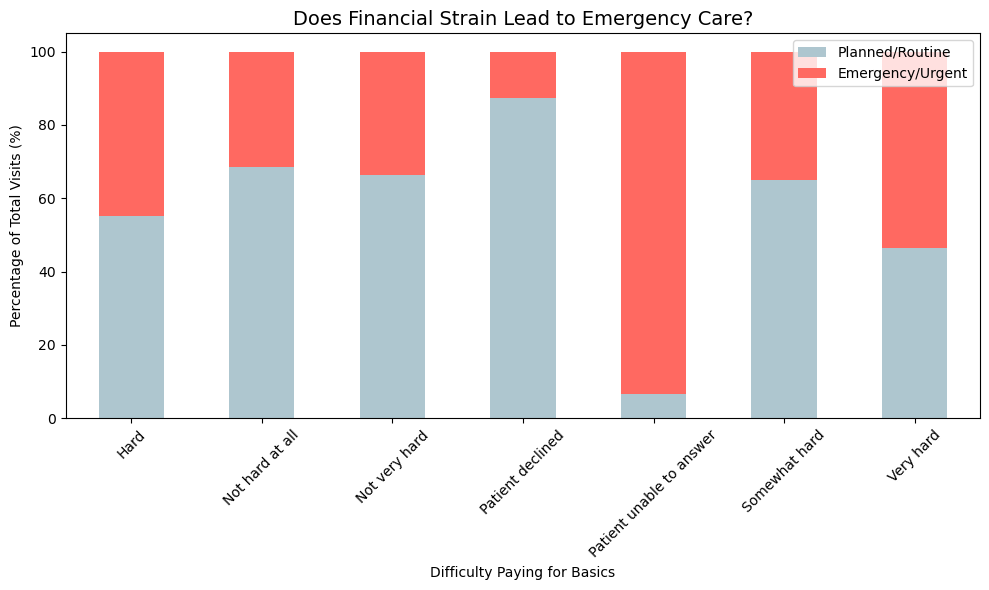

In [ ]:
plot_data = df_insight.groupby(['AnswerText', 'is_crisis_visit']).size().unstack(fill_value=0)
plot_data_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

ax = plot_data_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#AEC6CF', '#FF6961'])

plt.title('Does Financial Strain Lead to Emergency Care?', fontsize=14)
plt.ylabel('Percentage of Total Visits (%)')
plt.xlabel('Difficulty Paying for Basics')
plt.legend(['Planned/Routine', 'Emergency/Urgent'], loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# DITAMBAH QUESTION Financial Resource Strain dan Food Insecurity

In [ ]:
# List all 5 economic questions
economic_questions = [
    "How hard is it for you to pay for the very basics like food, housing, medical care, and heating?",
    "In the past 12 months has the electric, gas, oil, or water company threatened to shut off services in your home?",
    "In the last 12 months, was there a time when you were not able to pay the mortgage or rent on time?",
    "Within the past 12 months, you worried that your food would run out before you got the money to buy more.",
    "Within the past 12 months, the food you bought just didn't last and you didn't have money to get more."
]

df_econ_subset = df_soc[df_soc['DisplayName'].isin(economic_questions)].copy()

df_econ_wide = df_econ_subset.pivot_table(
    index='EncounterKey', 
    columns='DisplayName', 
    values='AnswerText', 
    aggfunc='first'
).reset_index()

master_econ = master_slim.merge(df_econ_wide, on='EncounterKey', how='left')

In [ ]:
def count_struggles(row):
    score = 0
    # Questions from the screenshot/PDF[cite: 2]
    if row.get("In the past 12 months has the electric, gas, oil, or water company threatened to shut off services in your home?") == 'Yes':
        score += 1
    if row.get("In the last 12 months, was there a time when you were not able to pay the mortgage or rent on time?") == 'Yes':
        score += 1
    if "Yes" in str(row.get("Within the past 12 months, you worried that your food would run out before you got the money to buy more.")):
        score += 1
    if "Yes" in str(row.get("Within the past 12 months, the food you bought just didn't last and you didn't have money to get more.")):
        score += 1
    if row.get("How hard is it for you to pay for the very basics like food, housing, medical care, and heating?") in ['Somewhat hard', 'Very hard']:
        score += 1
    return score

master_econ['Struggle_Index'] = master_econ.apply(count_struggles, axis=1)

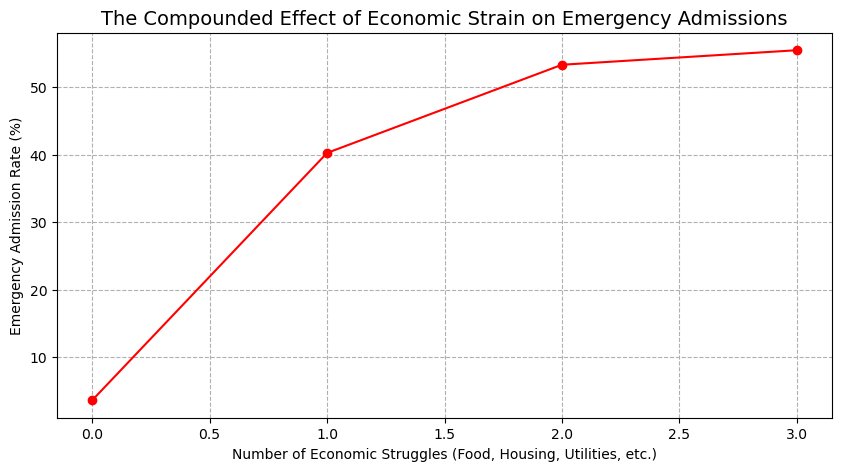

In [ ]:
master_econ['is_crisis'] = master_econ['AdmissionType'].isin(['Emergency', 'Urgent'])
index_analysis = master_econ.groupby('Struggle_Index')['is_crisis'].mean() * 100

index_analysis.plot(kind='line', marker='o', color='red', figsize=(10, 5))
plt.title('The Compounded Effect of Economic Strain on Emergency Admissions', fontsize=14)
plt.xlabel('Number of Economic Struggles (Food, Housing, Utilities, etc.)')
plt.ylabel('Emergency Admission Rate (%)')
plt.grid(True, linestyle='--')
plt.show()

# DITAMBAH PERTANYAAN HOUSING STABILITY

In [ ]:
# Updated list: 5 Economic/Food questions + 2 Housing questions
economic_questions = [
    "How hard is it for you to pay for the very basics like food, housing, medical care, and heating?",
    "In the past 12 months has the electric, gas, oil, or water company threatened to shut off services in your home?",
    "In the last 12 months, was there a time when you were not able to pay the mortgage or rent on time?",
    "Within the past 12 months, you worried that your food would run out before you got the money to buy more.",
    "Within the past 12 months, the food you bought just didn't last and you didn't have money to get more.",
    "In the last 12 months, was there a time when you did not have a steady place to sleep or slept in a shelter (including now)?",
    "At any time in the past 12 months, were you homeless or living in a shelter (including now)?"
]

df_econ_subset = df_soc[df_soc['DisplayName'].isin(economic_questions)].copy()

df_econ_wide = df_econ_subset.pivot_table(
    index='EncounterKey', 
    columns='DisplayName', 
    values='AnswerText', 
    aggfunc='first'
).reset_index()

master_econ = master_slim.merge(df_econ_wide, on='EncounterKey', how='left')

In [ ]:
question_col = "How hard is it for you to pay for the very basics like food, housing, medical care, and heating?"
print(master_econ[question_col].unique())

[nan 'Not hard at all' 'Patient declined' 'Not very hard' 'Somewhat hard'
 'Hard' 'Very hard' 'Patient unable to answer']


In [ ]:
def count_struggles(row):
    score = 0
    
    # Financial & Utilities 
    if row.get("In the past 12 months has the electric, gas, oil, or water company threatened to shut off services in your home?") == 'Yes':
        score += 1
    if row.get("In the last 12 months, was there a time when you were not able to pay the mortgage or rent on time?") == 'Yes':
        score += 1
    if row.get("How hard is it for you to pay for the very basics like food, housing, medical care, and heating?") in ['Somewhat hard', 'Very hard', 'Hard']:
        score += 1
        
    # Food Insecurity 
    if "Yes" in str(row.get("Within the past 12 months, you worried that your food would run out before you got the money to buy more.")):
        score += 1
    if "Yes" in str(row.get("Within the past 12 months, the food you bought just didn't last and you didn't have money to get more.")):
        score += 1
        
    # Housing Stability
    if row.get("In the last 12 months, was there a time when you did not have a steady place to sleep or slept in a shelter (including now)?") == 'Yes':
        score += 1
    if row.get("At any time in the past 12 months, were you homeless or living in a shelter (including now)?") == 'Yes':
        score += 1
        
    return score

master_econ['Struggle_Index'] = master_econ.apply(count_struggles, axis=1)

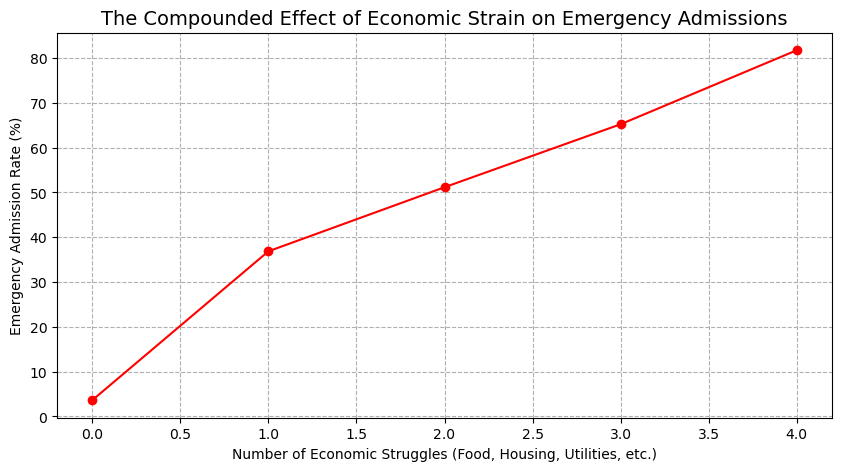

In [ ]:
master_econ['is_crisis'] = master_econ['AdmissionType'].isin(['Emergency', 'Urgent'])
index_analysis = master_econ.groupby('Struggle_Index')['is_crisis'].mean() * 100

index_analysis.plot(kind='line', marker='o', color='red', figsize=(10, 5))
plt.title('The Compounded Effect of Economic Strain on Emergency Admissions', fontsize=14)
plt.xlabel('Number of Economic Struggles (Food, Housing, Utilities, etc.)')
plt.ylabel('Emergency Admission Rate (%)')
plt.grid(True, linestyle='--')
plt.show()

In [22]:
master_econ.shape

(8099023, 18)

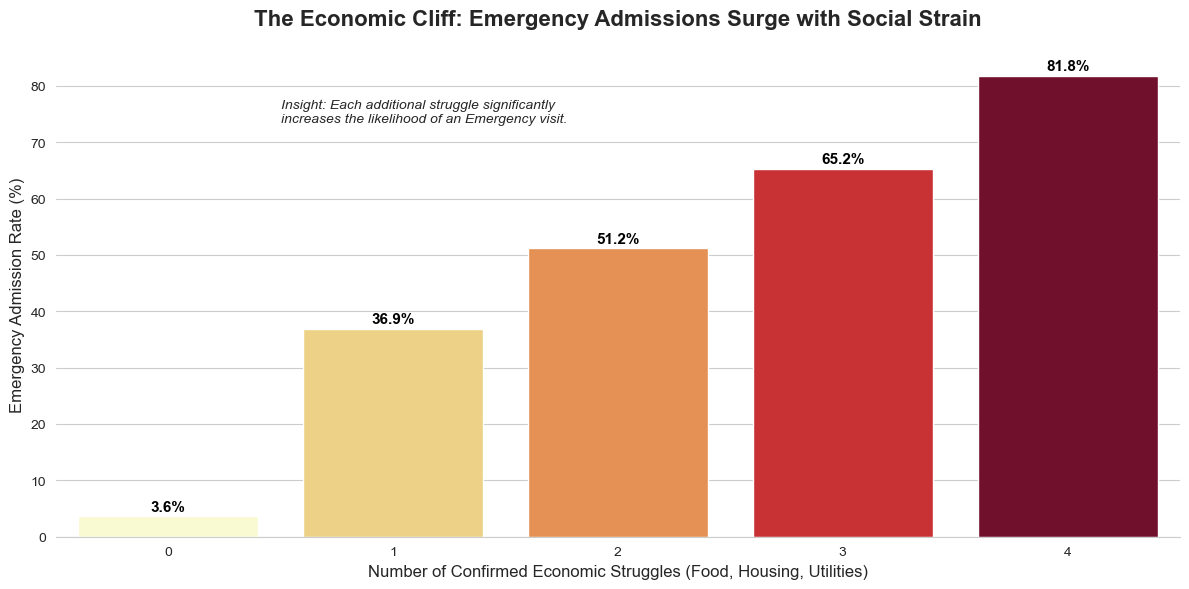

In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid") # Clean background

colors = sns.color_palette("YlOrRd", len(index_analysis))

ax = sns.barplot(
    x=index_analysis.index, 
    y=index_analysis.values, 
    palette="YlOrRd",
    hue=index_analysis.index,
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=11, color='black', 
                xytext=(0, 7), 
                textcoords='offset points',
                fontweight='bold')

# Title
plt.title('The Economic Cliff: Emergency Admissions Surge with Social Strain', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Confirmed Economic Struggles (Food, Housing, Utilities)', fontsize=12)
plt.ylabel('Emergency Admission Rate (%)', fontsize=12)

# Clean up the frame 
sns.despine(left=True, bottom=False)

plt.text(0.5, index_analysis.max() * 0.9, 
         "Insight: Each additional struggle significantly \nincreases the likelihood of an Emergency visit.", 
         fontsize=10, fontstyle='italic', bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()